<a href="https://colab.research.google.com/github/annacarolp/Fontes-de-dados/blob/main/ANALISESORVETES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Análise de dados sobre sorvetes

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sakshisatre/ice-cream-sales-dataset")

print("caminho para os arquivos conjunto de dados:", path)

Using Colab cache for faster access to the 'ice-cream-sales-dataset' dataset.
caminho para os arquivos conjunto de dados: /kaggle/input/ice-cream-sales-dataset


In [2]:
import pandas as pd

file_path = f"{path}/Ice Cream.csv"
df = pd.read_csv(file_path)

df.head(5)

,Temperature,Revenue
0,24.6,535
1,26.1,626
2,27.8,661
3,20.6,488
4,11.6,317


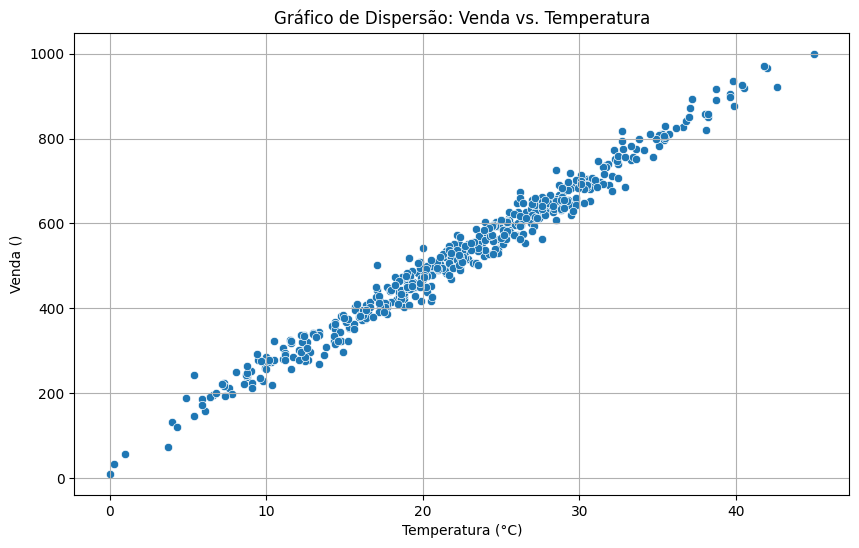

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Revenue', data=df)
plt.title('Gráfico de Dispersão: Venda vs. Temperatura')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Venda ()')
plt.grid(True)
plt.show()

Coefficient (Slope): 21.38
Intercept: 46.18
R-squared: 0.98


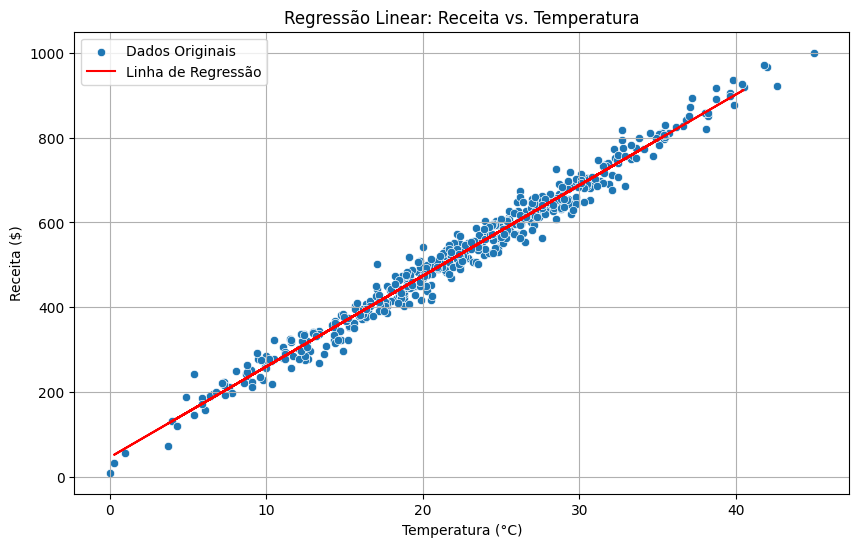

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target (y)
X = df[['Temperature']]
y = df['Revenue']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r_squared = r2_score(y_test, y_pred)

print(f"Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"R-squared: {r_squared:.2f}")

# Plotting the regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Revenue', data=df, label='Dados Originais')
plt.plot(X_test, y_pred, color='red', label='Linha de Regressão')
plt.title('Regressão Linear: Receita vs. Temperatura')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Receita ($)')
plt.legend()
plt.grid(True)
plt.show()